[ 39.93853958 -21.71398427  39.92702319  -9.1243164  629.99427873]
-0.017803206520403216


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from Scripts.Mass_Analysis.drone_mass import DroneMass
from Scripts.Mass_Analysis.drone_battery import Battery
from Scripts.drone_geometry import DroneGeometry
from Scripts.Finite_Elements.Beam_FEA_System.beam_type import BeamType
from Scripts.Finite_Elements.drone_fea import DroneFEA
import Scripts.unit_conversions as uc
from scipy.optimize import NonlinearConstraint
import scipy
from matplotlib.lines import Line2D

# np.array([Failure_Constraint, Deflection_Constraint, Natural_Frequency_Lower_Constraint, Natural_Frequency_Upper_Constraint, lb1, lb2,lb3,lb4,lb5, ub1, ub2, ub3, ub4, ub5])
Active_Constraints = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13])

Initial_Guess = np.array([0.45,   0.6, 0.45,     0.8, 0.6 ])
Scaling_Factor = np.array([100,1,100,1,1000])

stress_FOS = 4
allowable_deflection = 50.0 # mm
nf_clearence = 1.2

drag_coeff = 0.256
Propeller_RPM = 3068
Propeller_Forcing_Function_Hz = Propeller_RPM / 30
Propeller_Forcing_Function_Rad = Propeller_Forcing_Function_Hz * uc.Hz_to_rad_per_s
Propeller_radius = 406.4
Propeller_spacing = 25
arm_length = (Propeller_spacing + Propeller_radius) / math.sin(22.5 * math.pi/180)

battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))

def failure_constraint(x):
    arm_d1,arm_t,strut_d1,strut_t,strut_dist = [x[0]*100,x[1],x[2]*100,x[3],x[4]*1000]

    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")

    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    d1_fea.beam_system.add_force(np.array([0,0,-66]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.solve_static()
    d1_fea.solve_failure()

    Failure_Constraint = d1_fea.beam_system.max_failure_crit * stress_FOS

    return Failure_Constraint


def deflection_constraint(x):
    arm_d1,arm_t,strut_d1,strut_t,strut_dist = [x[0]*100,x[1],x[2]*100,x[3],x[4]*1000]

    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")

    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    d1_fea.beam_system.add_force(np.array([0,0,-66]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.solve_static()

    max_disp = max(d1_fea.beam_system.mag_displacements)

    Deflection_Constraint =  max_disp / allowable_deflection

    return Deflection_Constraint

def mass(x):
    arm_d1,arm_t,strut_d1,strut_t,strut_dist = [x[0]*100,x[1],x[2]*100,x[3],x[4]*1000]
    # Beam properties
    # arm_beam_properties = BeamType("annulus", [29, 25], "Carbon Fiber", "arm_beam")
    # strut_beam_properties = BeamType("annulus", [14, 12], "Carbon Fiber", "strut_beam")
    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")

    # Drone geometry
    # drone_geometry = DroneGeometry("drone_test", 1000, 660, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

    drone_mass = DroneMass(drone_geometry)

    return drone_mass.lumped_mass_frame

def mass_gradient(x, h):
    h_mat = np.identity(5) * h
    x_mat = np.stack([x] * 5)
    x_ph = x_mat + h_mat
    x_mh = x_mat - h_mat
    m_ph = np.zeros([5])
    m_mh = np.zeros([5])
    for i in range(5):
        m_ph[i] = mass(x_ph[i])
        m_mh[i] = mass(x_mh[i])
    m_g = (m_ph - m_mh) / (2 * h)
    
    return m_g


def natural_frequency_upper_constraint(x):
    arm_d1,arm_t, strut_d1,strut_t,strut_dist = [x[0]*100,x[1],x[2]*100,x[3],x[4]*1000]
    # Beam properties
    # arm_beam_properties = BeamType("annulus", [29, 25], "Carbon Fiber", "arm_beam")
    # strut_beam_properties = BeamType("annulus", [14, 12], "Carbon Fiber", "strut_beam")
    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")


    # Drone geometry
    # drone_geometry = DroneGeometry("drone_test", 1000, 660, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    
    # FEA
    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    # d1_fea.beam_system.add_force(np.array([0,0,66]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.beam_system.solve_natural_frequencies()

    Natural_Frequencies_Hz = d1_fea.beam_system.natural_frequencies/(2*math.pi)
    Natural_Frequency_Upper_Constraint = Propeller_Forcing_Function_Hz / (Natural_Frequencies_Hz[2] * nf_clearence)

    return Natural_Frequency_Upper_Constraint


def natural_frequency_lower_constraint(x):
    arm_r1,arm_t,strut_r1,strut_t,strut_dist = [x[0]*100,x[1],x[2]*100,x[3],x[4]*1000]
    # Beam properties
    # arm_beam_properties = BeamType("annulus", [29, 25], "Carbon Fiber", "arm_beam")
    # strut_beam_properties = BeamType("annulus", [14, 12], "Carbon Fiber", "strut_beam")
    arm_beam_properties = BeamType("annulus", [arm_r1 + arm_t*2, arm_r1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_r1 + strut_t*2, strut_r1 ], "Carbon Fiber", "strut_beam")


    # Drone geometry
    # drone_geometry = DroneGeometry("drone_test", 1000, 660, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

    # FEA
    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    d1_fea.solve_fea()
    d1_fea.beam_system.solve_natural_frequencies()

    Natural_Frequencies_Hz = d1_fea.beam_system.natural_frequencies/(2*math.pi)
    Natural_Frequency_Lower_Constraint = nf_clearence * Natural_Frequencies_Hz[1] / Propeller_Forcing_Function_Hz

    return Natural_Frequency_Lower_Constraint




def calc_constraints(x, all):
    arm_r1,arm_t,strut_r1,strut_t,strut_dist = [x[0]*100,x[1],x[2]*100,x[3],x[4]*1000]

    arm_beam_properties = BeamType("annulus", [arm_r1 + arm_t*2, arm_r1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_r1 + strut_t*2, strut_r1 ], "Carbon Fiber", "strut_beam")
    
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() 
    d1_fea.create_drone_slice_beams() 
    d1_fea.boundary_conditions_slice()
    d1_fea.beam_system.add_force(np.array([0,0,-66]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.beam_system.solve_natural_frequencies()
    d1_fea.solve_static()
    d1_fea.solve_failure()

    max_disp = max(d1_fea.beam_system.mag_displacements)
    Natural_Frequencies_Hz = d1_fea.beam_system.natural_frequencies/(2*math.pi)

    Failure_Constraint = d1_fea.beam_system.max_failure_crit * stress_FOS - 1
    Deflection_Constraint =  max_disp / allowable_deflection - 1
    Natural_Frequency_Lower_Constraint = nf_clearence * Natural_Frequencies_Hz[1] / Propeller_Forcing_Function_Hz - 1
    Natural_Frequency_Upper_Constraint = Propeller_Forcing_Function_Hz / (Natural_Frequencies_Hz[2] * nf_clearence) - 1
    
    lb1 = (10 - arm_r1)/100
    lb2 = 0.25 - arm_t
    lb3 = (10 - strut_r1)/100
    lb4 = 0.25 - strut_t
    lb5 = (100 - strut_dist)/1000

    ub1 = (-50 + arm_r1)/100
    ub2 = -3.75 + arm_t
    ub3 = (-50 + strut_r1)/100
    ub4 = -3.75 + strut_t
    ub5 = (-1500 + strut_dist)/1000
    if all:
        return np.array([Failure_Constraint, Deflection_Constraint, Natural_Frequency_Lower_Constraint, Natural_Frequency_Upper_Constraint, lb1, lb2,lb3,lb4,lb5, ub1, ub2, ub3, ub4, ub5])
    else:
        # Returns the subset of active constraints
        return np.array([Failure_Constraint, Deflection_Constraint, Natural_Frequency_Lower_Constraint, Natural_Frequency_Upper_Constraint, lb1, lb2,lb3,lb4,lb5, ub1, ub2, ub3, ub4, ub5])[Active_Constraints]

    


def calc_constraint_jacobians(x, h):
    cons_num = len(Active_Constraints)
    c_jac = np.zeros(cons_num)
    h_mat = np.identity(5) * h
    x_mat = np.stack([x] * 5)
    x_ph = x_mat + h_mat
    x_mh = x_mat - h_mat
    c_ph = np.zeros([5,cons_num])
    c_mh = np.zeros([5,cons_num])
    for i in range(5):
        c_ph[i] = calc_constraints(x_ph[i],False)
        c_mh[i] = calc_constraints(x_mh[i],False)
    c_jac = (c_ph - c_mh) / (2 * h)

    return np.transpose(c_jac)

def test_constraints(x):
    return np.array([failure_constraint(x),
                     deflection_constraint(x),
                     natural_frequency_lower_constraint(x),
                     natural_frequency_upper_constraint(x),
                     mass(x)])


def vis_design_space(x_var, y_var, bounds, section, p,x_list):
    var_x_val = section[x_var]
    var_y_val = section[y_var]

    failure_grd = np.zeros([p, p])
    deflection_grd = np.zeros([p, p])
    nf_low_grd = np.zeros([p, p])
    nf_upper_grd = np.zeros([p, p])
    mass_grd = np.zeros([p, p])

    bounds_ext = [bounds[x_var][0], bounds[x_var][1], bounds[y_var][0], bounds[y_var][1]]

    X_space = np.linspace(bounds[x_var][0], bounds[x_var][1], p)
    Y_space = np.linspace(bounds[y_var][0], bounds[y_var][1], p)

    for x_i, x in enumerate(X_space):
        for y_i, y in enumerate(Y_space):
            test_point = section.copy()
            test_point[x_var] = x / Scaling_Factor[x_var]
            test_point[y_var] = y / Scaling_Factor[y_var]
            failure_grd[y_i, x_i] = failure_constraint(test_point) - 1
            deflection_grd[y_i, x_i] = deflection_constraint(test_point) - 1
            nf_low_grd[y_i, x_i] = natural_frequency_lower_constraint(test_point) - 1
            nf_upper_grd[y_i, x_i] = natural_frequency_upper_constraint(test_point) - 1
            mass_grd[y_i, x_i] = natural_frequency_upper_constraint(test_point) * 1000  # kg

    plt.figure(figsize=(10, 10))
    img = plt.imshow(mass_grd, cmap='turbo', interpolation='nearest', extent=bounds_ext, origin='lower', zorder=1)

    cbar = plt.colorbar(img)
    cbar.set_ticks(np.linspace(np.min(mass_grd), np.max(mass_grd), num=5))
    cbar.set_label('Mass (kg)')

    xv, yv = np.meshgrid(X_space, Y_space)
    lvls = np.array([0, 0.05])
    line_widths = [3,1]

    contours0 = plt.contour(xv, yv, failure_grd, levels=lvls, linewidths = line_widths, colors='g', zorder=2)
    contours1 = plt.contour(xv, yv, deflection_grd, levels=lvls, linewidths = line_widths,colors='y', zorder=2)
    contours3 = plt.contour(xv, yv, nf_upper_grd, levels=lvls, linewidths = line_widths,colors='b', zorder=2)
    contours2 = plt.contour(xv, yv, nf_low_grd, levels=lvls, linewidths = line_widths,colors='m', zorder=2)

    plt.clabel(contours0, inline=True, fontsize=8, fmt='%1.3f')
    plt.clabel(contours1, inline=True, fontsize=8, fmt='%1.3f')
    plt.clabel(contours2, inline=True, fontsize=8, fmt='%1.3f')
    plt.clabel(contours3, inline=True, fontsize=8, fmt='%1.3f')

    plt.gca().set_aspect('auto', adjustable='box')

    legend_elements = [
        Line2D([0], [0], color='g', lw=2, label='Failure Constraint'),
        Line2D([0], [0], color='y', lw=2, label='Deflection Constraint'),
        Line2D([0], [0], color='b', lw=2, label='Natural Frequency Upper'),
        Line2D([0], [0], color='m', lw=2, label='Natural Frequency Lower')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.scatter(var_x_val * Scaling_Factor[x_var], var_y_val * Scaling_Factor[y_var], c='r', zorder=4)
    if x_list is not None:
        plt.scatter(x_list[0:-1,x_var] * Scaling_Factor[x_var], x_list[0:-1,y_var] * Scaling_Factor[y_var], c='k', zorder=3, s=12)



def sqp(xi, h, max_iter, tol, R):
    x_list = [xi]
    x = xi
    Q = np.eye(len(x))
    steps = 0
    last_step = 0

    for iteration in range(max_iter):
        grad_f = mass_gradient(x, h)
        c = calc_constraints(x, False)  
        J = calc_constraint_jacobians(x, h) 

        active_set = np.where(c >= -1e-6)[0]  
        if len(active_set) > 0:
            A = J[active_set] 
            c_active = c[active_set]
        else:
            A = np.zeros((0, len(x)))
            c_active = np.zeros(0)

        KKT = np.block([
            [Q, A.T],
            [A, np.zeros((len(A), len(A)))]
        ])
        
        vector_kkt = np.concatenate([-grad_f, -c_active])

        try:
            KKT_sol = np.linalg.solve(KKT, vector_kkt)
        except np.linalg.LinAlgError:
            print("Singular KKT matrix at iteration", iteration)
            break

        d = KKT_sol[:len(x)]

        if np.linalg.norm(d) < 1e-10:
            print("Zero step at iteration", iteration)
            break

        # Line Search with penalty for constraint violation
        Interval_Size = 100
        x_p = np.double(x)
        x_u = np.double(x + Interval_Size * d)

        while Interval_Size > 1e-12:
            x_a = x_u * (1/3) + x_p * (2/3)
            x_b = x_u * (2/3) + x_p * (1/3)

            c_a = calc_constraints(x_a, False)
            c_b = calc_constraints(x_b, False)

            V_a = np.sum(np.maximum(0, c_a)**2)
            V_b = np.sum(np.maximum(0, c_b)**2)

            f_a = np.double(mass(x_a) + R * V_a)
            f_b = np.double(mass(x_b) + R * V_b)

            if f_a < f_b:
                x_u = x_b
            else:
                x_p = x_a

            Interval_Size = np.linalg.norm(x_u - x_p)
        print("step ",iteration,"| m=",mass(x_p), "| violation =",np.max(np.concatenate(([0], calc_constraints(x_p, False))))**2, " | error=",np.linalg.norm(x_p - x))
        if (np.linalg.norm(x_p - x)) < tol:
            print("steps", iteration, "iterations")
            break
            
        x = x_p
        x_list.append(x_p)
        steps = iteration

    return x, mass(x), np.array(x_list), steps


Results_x, Mass_x, x_list, steps = sqp(Initial_Guess,1e-12,500,1e-12,10000)

print(f'- Initial Guess -')
print(f'arm inner radius: {Initial_Guess[0]*Scaling_Factor[0]} mm')
print(f'arm thickness: {Initial_Guess[1]*Scaling_Factor[1]} mm')
print(f'strut inner radius: {Initial_Guess[2]*Scaling_Factor[2]} mm')
print(f'strut thickness: {Initial_Guess[3]*Scaling_Factor[3]} mm')
print(f'strut distance: {Initial_Guess[4]*Scaling_Factor[4]} mm')
print(f'Mass: {mass(Initial_Guess) * 1000} kg')
print(f'Constraints met: {calc_constraints(Initial_Guess,True)}')

print(f'- Optimized Result -')
print(f'Steps:  {steps}')
print(f'arm inner radius: {Results_x[0]*Scaling_Factor[0]} mm')
print(f'arm thickness: {Results_x[1]*Scaling_Factor[1]} mm')
print(f'strut inner radius: {Results_x[2]*Scaling_Factor[2]} mm')
print(f'strut thickness: {Results_x[3]*Scaling_Factor[3]} mm')
print(f'strut distance: {Results_x[4]*Scaling_Factor[4]} mm')
print(f'Mass: {Mass_x * 1000} kg')
print(f'Constraints met: {calc_constraints(Results_x,True)}')



step  0 | m= 0.0013427177052544184 | violation = 9.744895331755247e-16  | error= 0.03906458980361183
step  1 | m= 0.001334636274763304 | violation = 4.1917813541652257e-11  | error= 0.006637991813341259
step  2 | m= 0.0013183434418720175 | violation = 1.2445945623871486e-11  | error= 0.013420520965425408
step  3 | m= 0.0013027046430493703 | violation = 1.2151049997050245e-11  | error= 0.012918499417999704
step  4 | m= 0.0012923314832849438 | violation = 2.52797335937473e-11  | error= 0.00858848070076666
step  5 | m= 0.0012894609739780613 | violation = 1.128454974399888e-10  | error= 0.0023772767636909354
step  6 | m= 0.0012797753224183005 | violation = 3.1325342060943084e-11  | error= 0.008040067813378533
step  7 | m= 0.001277186626048713 | violation = 1.1852467486342968e-10  | error= 0.0021483863601234688
step  8 | m= 0.0012720539227587266 | violation = 1.0182055440209853e-10  | error= 0.00426712093472055
step  9 | m= 0.0012608679509525786 | violation = 2.103355333058816e-11  | error=

In [9]:
# M = C1 * (x[1] * x[2] + x[2] ** 2) + C2 * x[5] * (x[3] * x[4] + x[4] ** 2))


Boundaries = np.array([[3, 50], [0.25, 3.175], [20, 50], [0.25, 3.175], [100, 1500]])

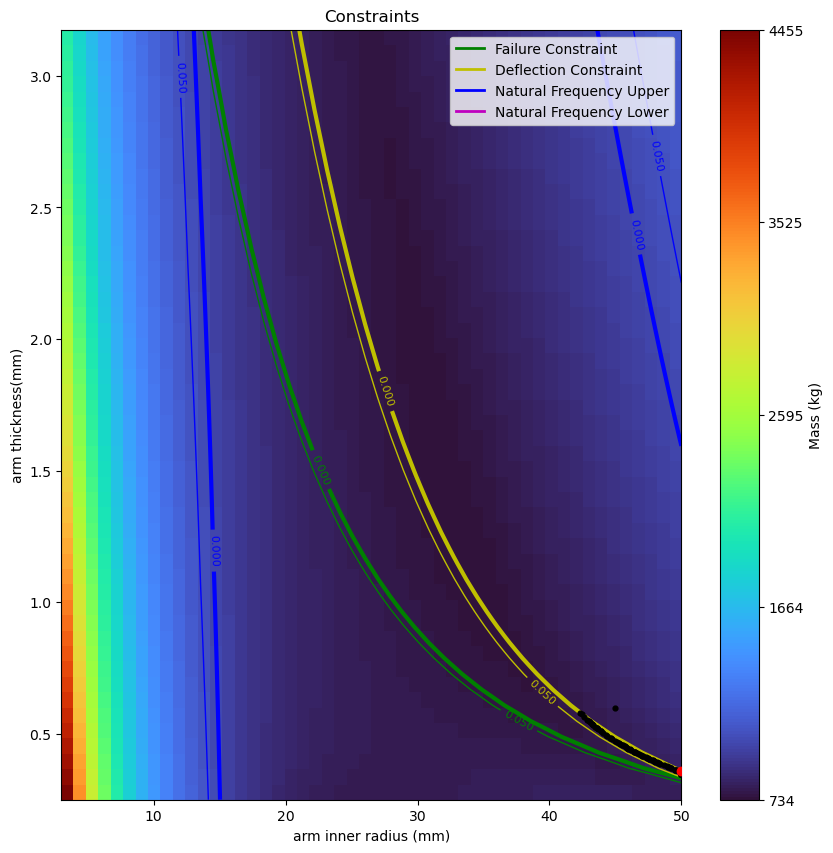

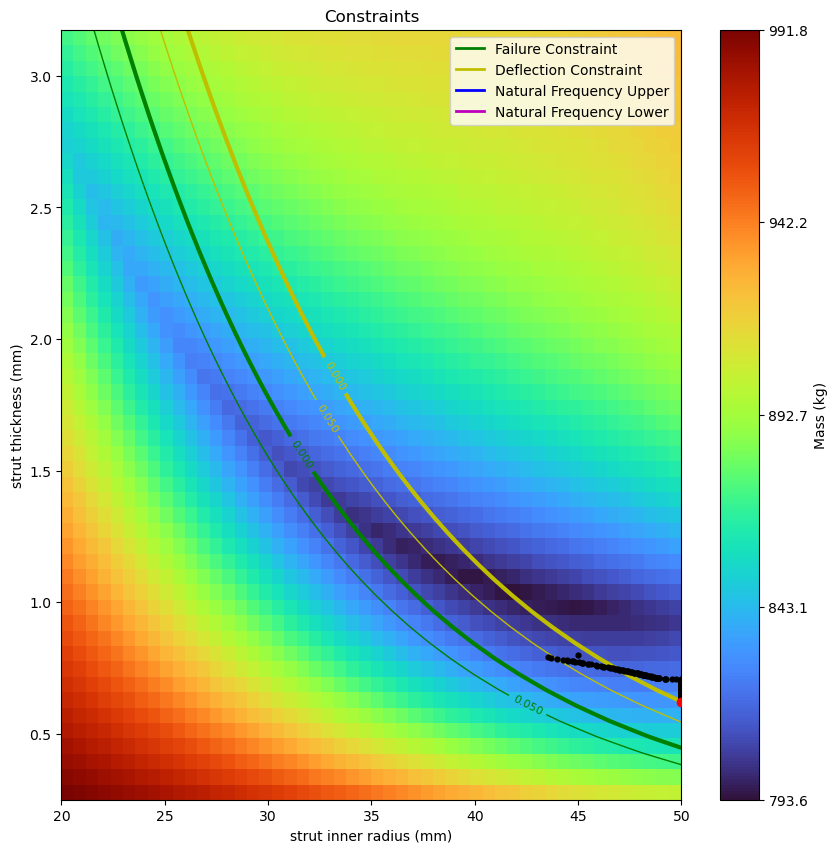

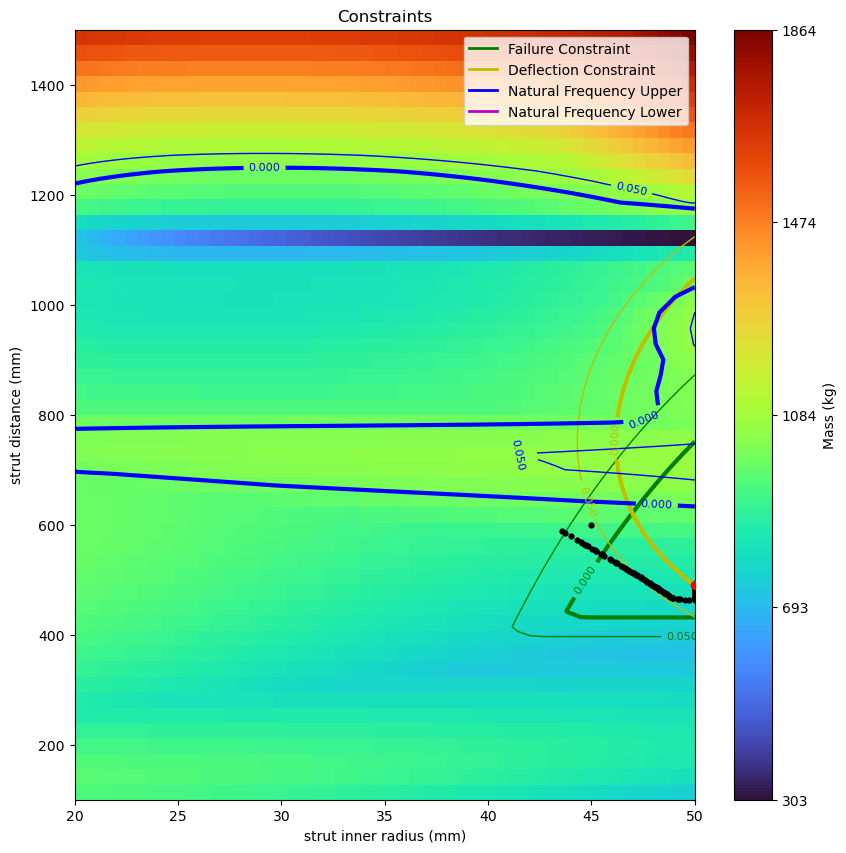

In [10]:

vis_design_space(0,1,Boundaries,np.array(Results_x),50,x_list)
plt.title('Constraints')
plt.xlabel('arm inner radius (mm)')
plt.ylabel('arm thickness(mm)')
plt.show()

vis_design_space(2,3,Boundaries,np.array(Results_x),50,x_list)
plt.title('Constraints')
plt.xlabel('strut inner radius (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

vis_design_space(2,4,Boundaries,np.array(Results_x),50,x_list)
plt.title('Constraints')
plt.xlabel('strut inner radius (mm)')
plt.ylabel('strut distance (mm)')
plt.show()


In [39]:
## VERIFICATION ## 


Initial_Guess = np.array([0.45, 1, 0.45, 1, 0.400])

Constraints = (
    NonlinearConstraint(deflection_constraint, 0, 1),
    NonlinearConstraint(failure_constraint, 0, 1)
)

Boundaries = np.array([[0.03, 0.50], [0.25, 3.175], [0.03, 0.50], [0.25, 3.175], [0.1, 1.5]])

Results = scipy.optimize.minimize(mass,Initial_Guess,bounds=Boundaries,constraints=Constraints,tol=1e-10)

Boundaries_2 = np.array([[3, 50], [0.25, 3.175], [3, 50], [0.25, 3.175], [100, 1500]])
print(Results)
print("Initial Guess:")
print("arm radius | arm thickness | strut radius | strut thickness | strut dist from center")
print(Initial_Guess * Scaling_Factor)
print("failure | deflection | mass")
print(test_constraints(Initial_Guess))
print("Mass (kg)", mass(Initial_Guess) * 1000)

print("\n")

print("Optimized:")
print("arm radius | arm thickness | strut radius | strut thickness | strut dist from center")
print(np.round((Results.x * Scaling_Factor),decimals=3))
print("failure | deflection | mass")
print(calc_constraints(Results.x,True))
print("Mass (kg)", mass(Results.x) * 1000)




 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0009848341061748798
       x: [ 5.000e-01  3.627e-01  5.000e-01  6.099e-01  4.904e-01]
     nit: 40
     jac: [ 1.251e-03  1.750e-03  7.007e-04  5.885e-04  7.231e-04]
    nfev: 242
    njev: 40
Initial Guess:
arm radius | arm thickness | strut radius | strut thickness | strut dist from center
[ 45.   1.  45.   1. 400.]
failure | deflection | mass
[0.45596353 0.59732353 0.60762817 0.76463192 0.00201835]
Mass (kg) 2.0183537429640745


Optimized:
arm radius | arm thickness | strut radius | strut thickness | strut dist from center
[5.00000e+01 3.63000e-01 5.00000e+01 6.10000e-01 4.90403e+02]
failure | deflection | mass
[-9.40682507e-02  1.29252165e-12 -3.97851882e-01 -1.66245236e-01
 -4.00000000e-01 -1.12653348e-01 -4.00000000e-01 -3.59861058e-01
 -3.90402888e-01 -1.42108547e-16 -3.38734665e+00 -2.84217094e-16
 -3.14013894e+00 -1.00959711e+00]
Mass (kg) 0.9848341061748799


In [ ]:
vis_design_space(0,1,Boundaries_2,np.array(Results.x),70,None)
plt.title('Constraints')
plt.xlabel('arm inner radius (mm)')
plt.ylabel('arm thickness(mm)')
plt.show()

vis_design_space(2,3,Boundaries_2,np.array(Results.x),70,None)
plt.title('Constraints')
plt.xlabel('strut radius (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

vis_design_space(2,4,Boundaries_2,np.array(Results.x),70,None)
plt.title('Constraints')
plt.xlabel('strut radius (mm)')
plt.ylabel('strut distance (mm)')
plt.show()

In [63]:
print(calc_constraints([0.5,     0.36265, 0.5,     0.60986, 0.4904 ],True))

[-9.40557172e-02  8.85781841e-06 -3.97851546e-01 -1.66248464e-01
 -4.00000000e-01 -1.12650000e-01 -4.00000000e-01 -3.59860000e-01
 -3.90400000e-01  0.00000000e+00 -3.38735000e+00  0.00000000e+00
 -3.14014000e+00 -1.00960000e+00]
